# 3. Projekat iz predmeta **Mašinsko učenje**
**Dataset:**  
[Sleep Patterns vs Daily Performance](https://www.kaggle.com/datasets/arsalanjamal002/sleep-patterns-vs-daily-performance)

## Setup i učitavanje
### Import biblioteka i setovanje konstantni

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

### Učitavanje podataka i pregled strukture

In [2]:
dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')

dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sleep_Hours              30000 non-null  float64
 1   Sleep_Quality_Score      30000 non-null  int64  
 2   Caffeine_Intake_mg       30000 non-null  float64
 3   Screen_Time_Before_Bed   30000 non-null  float64
 4   Morning_Mood             30000 non-null  object 
 5   Work_Productivity_Score  30000 non-null  int64  
 6   Error_Rate               30000 non-null  float64
 7   Energy_Level             30000 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 1.8+ MB


,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Work_Productivity_Score,Error_Rate,Energy_Level
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,6.987010,7.590433,198.492067,58.685500,73.637667,6.499266,8.656567
std,1.468244,1.518826,133.939111,54.993704,13.119905,3.785921,1.330669
min,2.000000,1.000000,1.000000,0.000000,6.000000,0.000000,1.000000
25%,6.000000,7.000000,97.000000,17.000000,66.000000,3.757500,8.000000
50%,7.000000,8.000000,169.000000,42.000000,75.000000,6.140000,9.000000
75%,8.000000,9.000000,271.000000,84.000000,83.000000,8.890000,10.000000
max,10.000000,10.000000,600.000000,240.000000,100.000000,26.900000,10.000000


In [3]:
dataset.head()

,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Morning_Mood,Work_Productivity_Score,Error_Rate,Energy_Level
0,7.7,7,498.0,107.0,Neutral,71,10.45,8
1,6.8,8,315.0,128.0,Good,80,6.49,10
2,8.0,10,412.0,34.0,Excellent,85,3.88,10
3,9.3,9,447.0,28.0,Good,85,3.18,10
4,6.6,7,177.0,57.0,Neutral,70,6.74,8


## Preprocesiranje podataka

### Uklanjanje duplikata

In [4]:
broj_duplikata = dataset.duplicated().sum()
print(f'Broj duplikata: {broj_duplikata}')

Broj duplikata: 0


### Analiza podataka

#### Analiza nedostajućih vrednosti

In [5]:
dataset.isnull().sum()

Sleep_Hours                0
Sleep_Quality_Score        0
Caffeine_Intake_mg         0
Screen_Time_Before_Bed     0
Morning_Mood               0
Work_Productivity_Score    0
Error_Rate                 0
Energy_Level               0
dtype: int64

### Enkodiranje kolone: <b>Morning_Mood</b>

Kolona <i>Morning_Mood</i> je ordinalna kategorička promenljiva sa prirodnim redosledom:
<i>Very Bad → Bad → Neutral → Good → Excellent</i>

Koristimo ordinalno enkodiranje koje čuva ovaj redosled, za razliku od One-Hot Encodinga koji bi
tretirao klase kao nezavisne. Ovo je ispravniji izbor jer model može da iskoristi ordinalnu strukturu.

In [6]:
mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
mood_map   = {m: i for i, m in enumerate(mood_order)}

dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)

print('Mapiranje Morning_Mood:')
for k, v in mood_map.items():
    print(f'  {v} -> {k}')
print()
print('Distribucija:')
print(dataset['Morning_Mood'].value_counts().sort_index())

Mapiranje Morning_Mood:
  0 -> Very Bad
  1 -> Bad
  2 -> Neutral
  3 -> Good
  4 -> Excellent

Distribucija:
Morning_Mood
0      344
1     2228
2     7862
3    12831
4     6735
Name: count, dtype: int64


### Analiza i tretman outliera

Proveravamo IQR-based outliere za numeričke kolone. Outlieri se <b>ne uklanjaju</b> jer:
- Predstavljaju realne vrednosti (npr. 600mg kofeina dnevno je ekstremno ali moguće)
- Zadržavaju informativnu vrednost za model
- Procenat outliera je mali (< 5% po koloni)

In [7]:
cols_to_check = ['Caffeine_Intake_mg', 'Screen_Time_Before_Bed', 'Error_Rate', 'Sleep_Hours']

print(f'{"Kolona":<28} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Outlieri":>10} {"Procenat":>10}')
print('-' * 75)
for col in cols_to_check:
    Q1  = dataset[col].quantile(0.25)
    Q3  = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (dataset[col] < Q1 - 1.5 * IQR) | (dataset[col] > Q3 + 1.5 * IQR)
    n_out = mask.sum()
    print(f'{col:<28} {Q1:>7.1f} {Q3:>7.1f} {IQR:>7.1f} {n_out:>10} {n_out/len(dataset)*100:>9.2f}%')

print()
print('Zakljucak: outlieri se zadrzavaju — vrednosti su realne i procenat je nizak.')

Kolona                            Q1      Q3     IQR   Outlieri   Procenat
---------------------------------------------------------------------------
Caffeine_Intake_mg              97.0   271.0   174.0        896      2.99%
Screen_Time_Before_Bed          17.0    84.0    67.0       1343      4.48%
Error_Rate                       3.8     8.9     5.1        288      0.96%
Sleep_Hours                      6.0     8.0     2.0        117      0.39%

Zakljucak: outlieri se zadrzavaju — vrednosti su realne i procenat je nizak.


## EDA

#### Distribucija targeta — <i>Work_Productivity_Score</i>

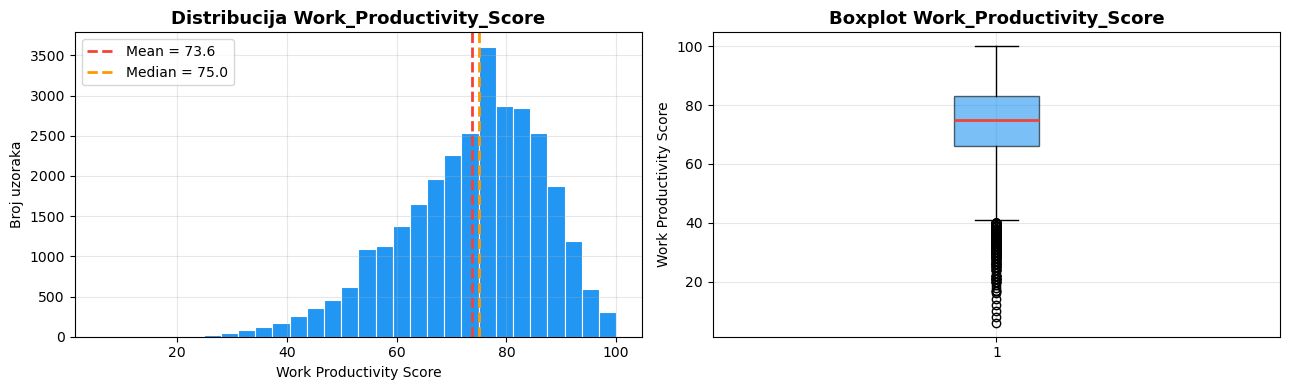

Min:    6
Max:    100
Mean:   73.64
Median: 75.00
Std:    13.12


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dataset['Work_Productivity_Score'], bins=30,
             color='#2196F3', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribucija Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Work Productivity Score')
axes[0].set_ylabel('Broj uzoraka')
axes[0].axvline(dataset['Work_Productivity_Score'].mean(), color='#F44336',
                linewidth=2, linestyle='--', label=f'Mean = {dataset["Work_Productivity_Score"].mean():.1f}')
axes[0].axvline(dataset['Work_Productivity_Score'].median(), color='#FF9800',
                linewidth=2, linestyle='--', label=f'Median = {dataset["Work_Productivity_Score"].median():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(dataset['Work_Productivity_Score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Boxplot Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Work Productivity Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Min:    {dataset["Work_Productivity_Score"].min():.0f}')
print(f'Max:    {dataset["Work_Productivity_Score"].max():.0f}')
print(f'Mean:   {dataset["Work_Productivity_Score"].mean():.2f}')
print(f'Median: {dataset["Work_Productivity_Score"].median():.2f}')
print(f'Std:    {dataset["Work_Productivity_Score"].std():.2f}')

#### Korelaciona matrica feature-a

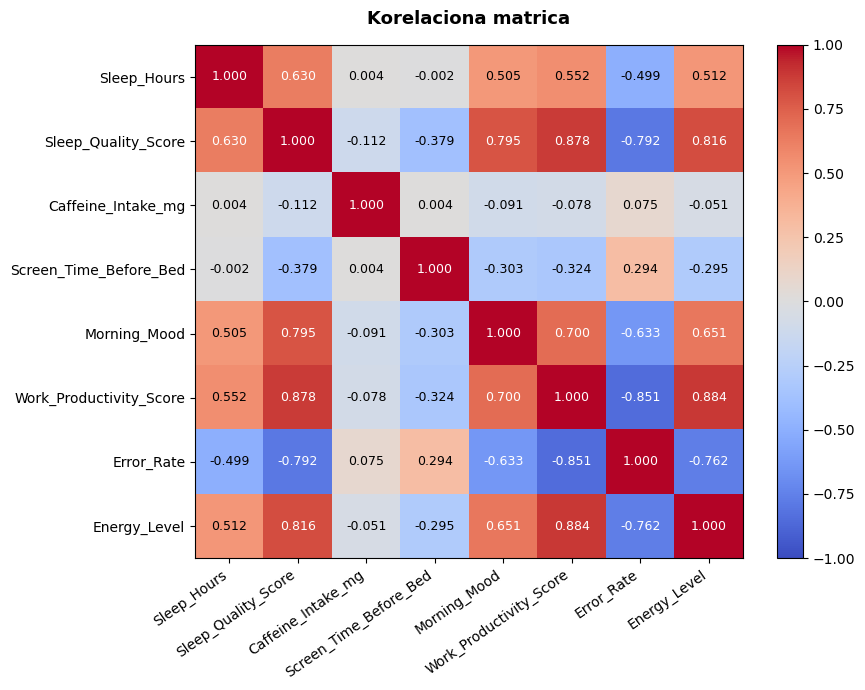

Korelacija sa Work_Productivity_Score (sortirano):
Energy_Level              0.884053
Sleep_Quality_Score       0.877801
Morning_Mood              0.700160
Sleep_Hours               0.552399
Caffeine_Intake_mg       -0.077774
Screen_Time_Before_Bed   -0.323615
Error_Rate               -0.851021


In [9]:
corr = dataset.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Korelaciona matrica', fontsize=13, fontweight='bold', pad=15)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Korelacija sa Work_Productivity_Score (sortirano):')
print(corr['Work_Productivity_Score'].drop('Work_Productivity_Score').sort_values(ascending=False).to_string())

#### Scatter plot — feature-i vs <i>Work_Productivity_Score</i>

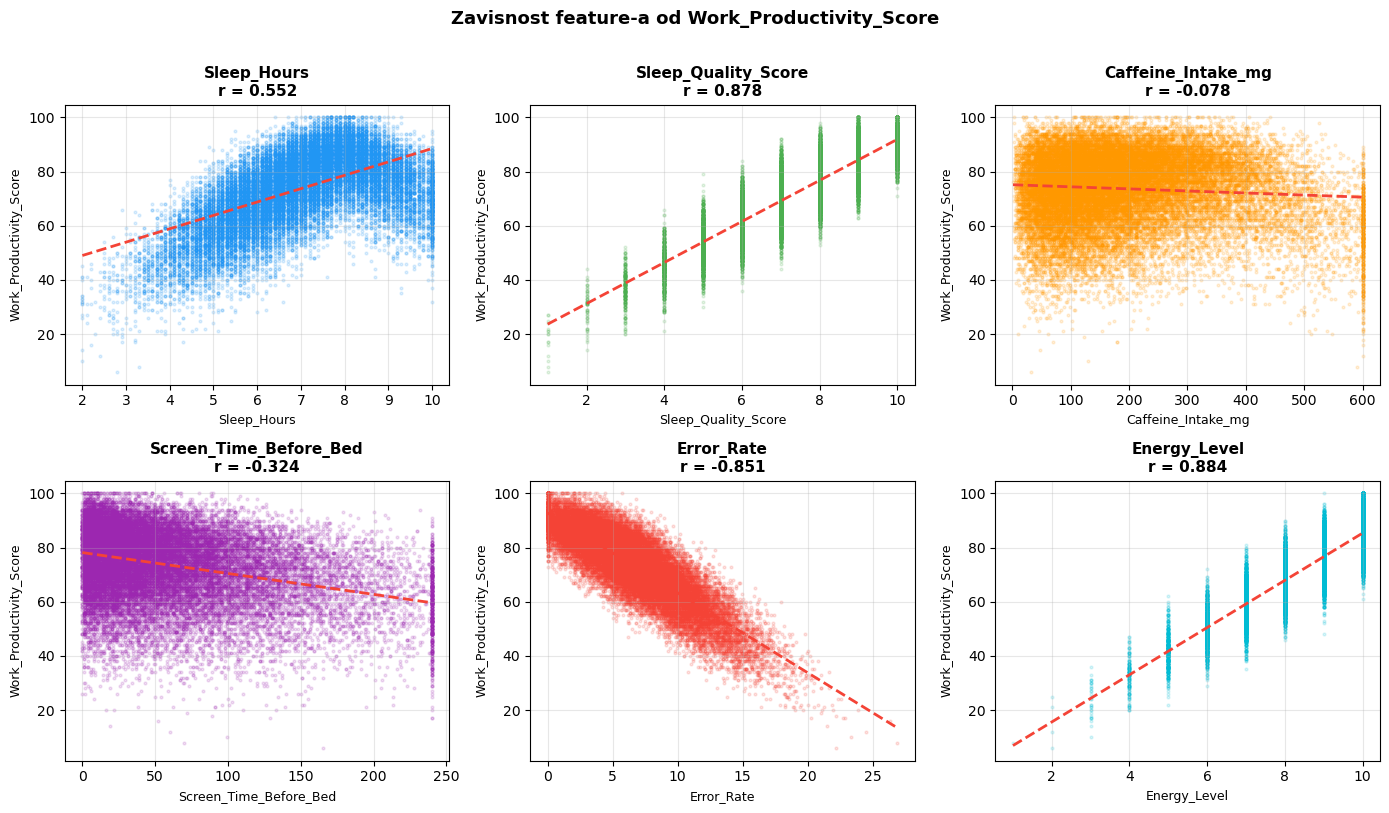

In [10]:
num_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors_scatter = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for i, col in enumerate(num_features):
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    axes[i].scatter(dataset[col], dataset['Work_Productivity_Score'],
                    alpha=0.15, s=4, color=colors_scatter[i])
    z = np.polyfit(dataset[col], dataset['Work_Productivity_Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(dataset[col].min(), dataset[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#F44336', linewidth=2, linestyle='--')
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Work_Productivity_Score', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Zavisnost feature-a od Work_Productivity_Score',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### <i>Morning_Mood</i> vs <i>Work_Productivity_Score</i>

C:\Users\Asus\AppData\Local\Temp\ipykernel_16480\3239374769.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,


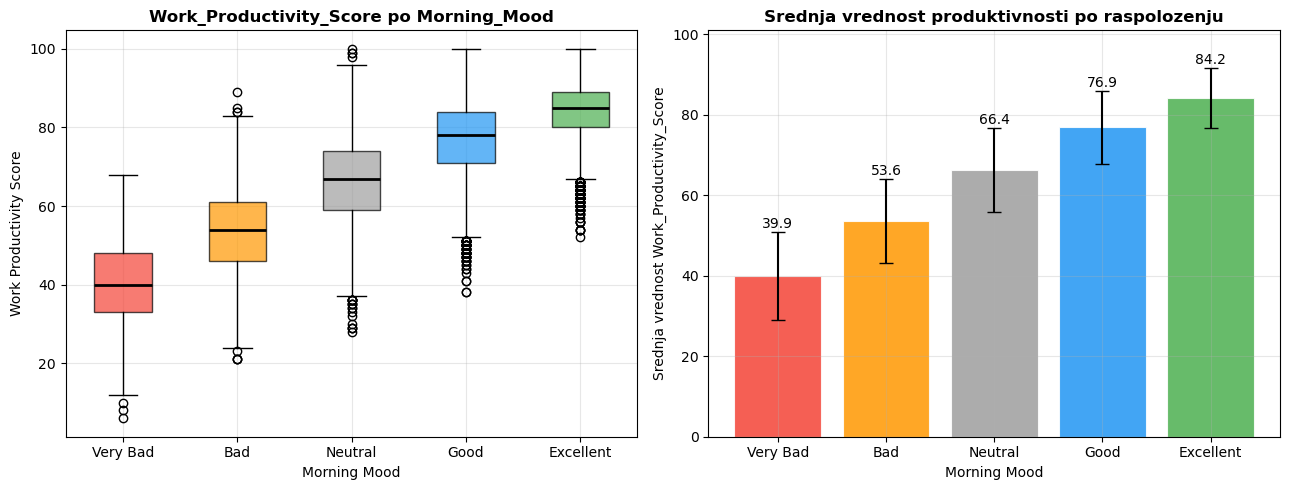

In [11]:
mood_labels = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
colors_mood = ['#F44336', '#FF9800', '#9E9E9E', '#2196F3', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mood_groups = [dataset[dataset['Morning_Mood'] == i]['Work_Productivity_Score']
               for i in range(5)]
bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_mood):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Work_Productivity_Score po Morning_Mood', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Morning Mood')
axes[0].set_ylabel('Work Productivity Score')
axes[0].grid(True, alpha=0.3)

means = [g.mean() for g in mood_groups]
stds  = [g.std() for g in mood_groups]
axes[1].bar(mood_labels, means, color=colors_mood, edgecolor='white',
            linewidth=0.8, alpha=0.85, yerr=stds, capsize=5)
axes[1].set_title('Srednja vrednost produktivnosti po raspolozenju', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Morning Mood')
axes[1].set_ylabel('Srednja vrednost Work_Productivity_Score')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 1, f'{m:.1f}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(means) * 1.2)

plt.tight_layout()
plt.show()

#### Heatmapa: <i>Sleep_Hours</i> × <i>Sleep_Quality_Score</i> → <i>Work_Productivity_Score</i>

C:\Users\Asus\AppData\Local\Temp\ipykernel_16480\2373501981.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = dataset.pivot_table(


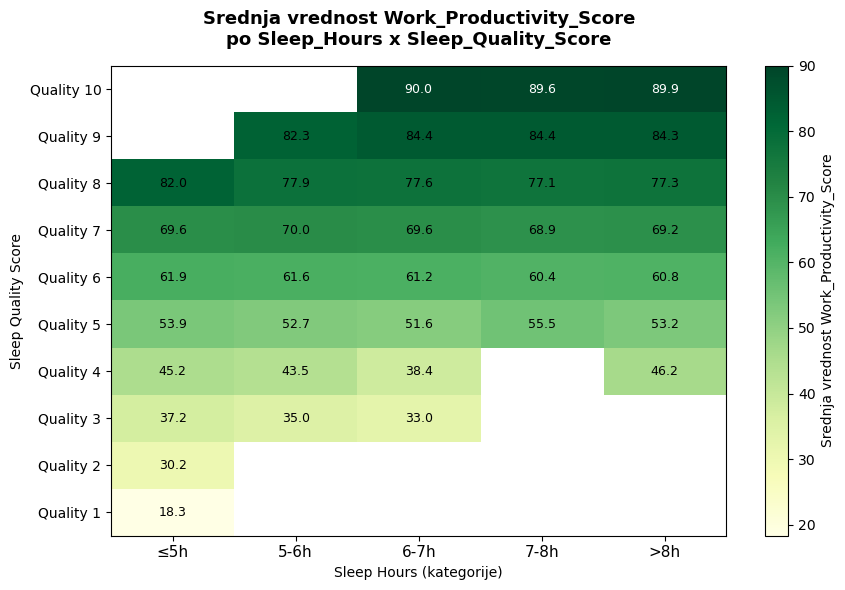

In [12]:
dataset['sleep_bin'] = pd.cut(dataset['Sleep_Hours'],
                               bins=[1.9, 5, 6, 7, 8, 10.1],
                               labels=['≤5h', '5-6h', '6-7h', '7-8h', '>8h'])

pivot = dataset.pivot_table(
    values='Work_Productivity_Score',
    index='Sleep_Quality_Score',
    columns='sleep_bin',
    aggfunc='mean'
)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
               vmin=pivot.values[~np.isnan(pivot.values)].min(),
               vmax=pivot.values[~np.isnan(pivot.values)].max())

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'Quality {v}' for v in pivot.index], fontsize=10)
ax.set_title('Srednja vrednost Work_Productivity_Score\npo Sleep_Hours x Sleep_Quality_Score',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sleep Hours (kategorije)')
ax.set_ylabel('Sleep Quality Score')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                    color='black' if val < 85 else 'white')

plt.colorbar(im, ax=ax, label='Srednja vrednost Work_Productivity_Score')
plt.tight_layout()
plt.show()

dataset = dataset.drop(columns=['sleep_bin'])

#### Distribucija svih feature-a

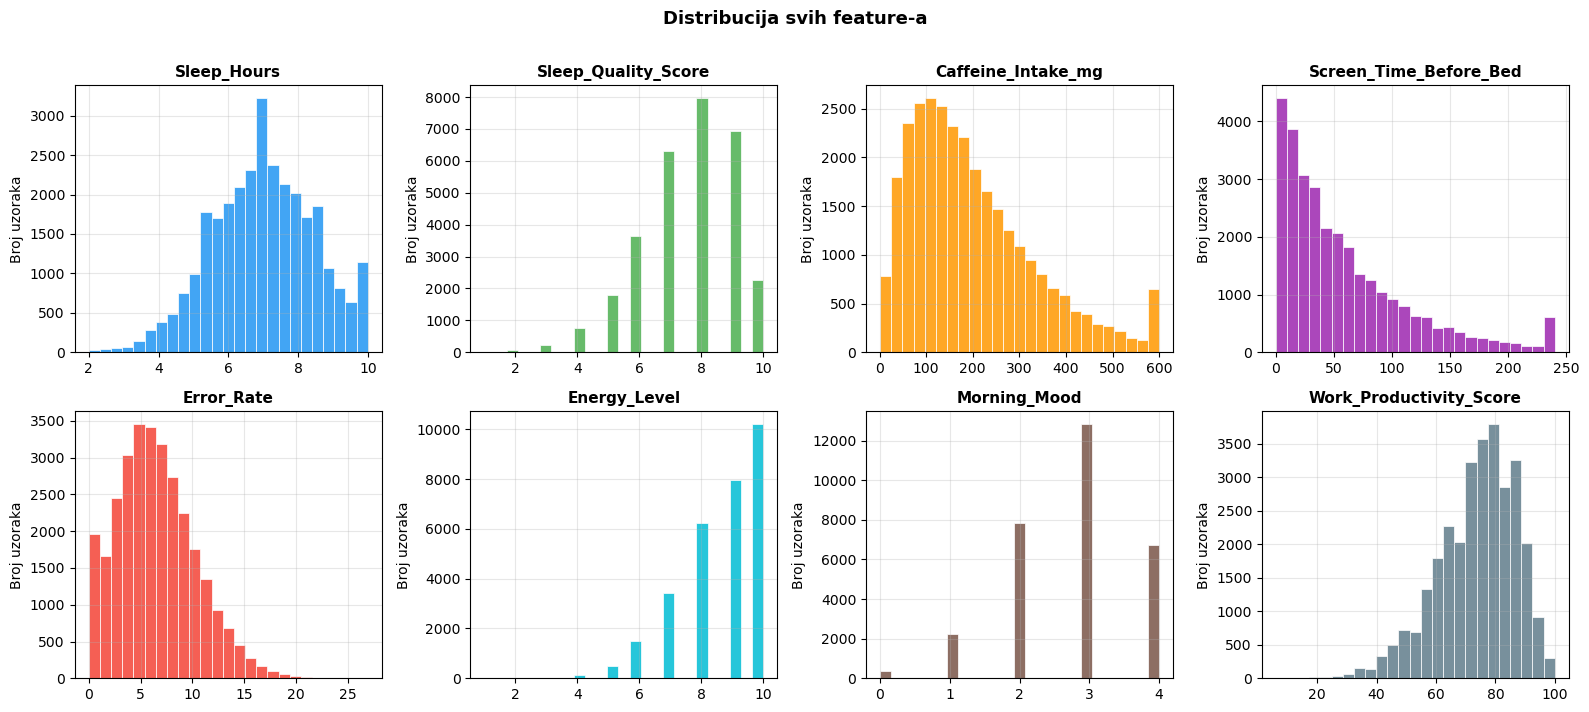

In [13]:
all_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level',
                'Morning_Mood', 'Work_Productivity_Score']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548','#607D8B']

for i, col in enumerate(all_features):
    axes[i].hist(dataset[col], bins=25, color=palette[i],
                 edgecolor='white', linewidth=0.6, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribucija svih feature-a', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = dataset.drop(columns=['Work_Productivity_Score']).astype(float).values
y = dataset['Work_Productivity_Score'].values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train:      {X_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_test_s.shape[0]:,} uzoraka")
print(f"Broj feature-a: {X_train_s.shape[1]}")
print(f"\nTarget statistike (train):")
print(f"  Mean:  {y_train.mean():.2f}")
print(f"  Std:   {y_train.std():.2f}")
print(f"  Min:   {y_train.min():.0f}")
print(f"  Max:   {y_train.max():.0f}")

Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka
Broj feature-a: 7

Target statistike (train):
  Mean:  73.67
  Std:   13.12
  Min:   8
  Max:   100


In [16]:
y_mean_pred = np.full_like(y_test, fill_value=y_train.mean())

mae_baseline  = mean_absolute_error(y_test, y_mean_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_mean_pred))
r2_baseline   = r2_score(y_test, y_mean_pred)

print("=" * 50)
print("BASELINE — Mean Predictor")
print("=" * 50)
print(f"  MAE:  {mae_baseline:.4f}")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R²:   {r2_baseline:.4f}")
print()
print(f"Uvek predviđa: {y_train.mean():.2f}")
print("(Ovo je minimalni prag koji svaki model mora da premaši)")

BASELINE — Mean Predictor
  MAE:  10.3249
  RMSE: 12.9558
  R²:   -0.0001

Uvek predviđa: 73.67
(Ovo je minimalni prag koji svaki model mora da premaši)


In [17]:
def build_baseline_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="Baseline_SleepNet")
    return model

baseline_model = build_baseline_model(input_dim=X_train_s.shape[1])
baseline_model.summary()

Model: "Baseline_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [19]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [20]:
history = baseline_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history.history['loss'])}")
print(f"Finalna train MAE:      {history.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history.history['val_mae'][-1]:.4f}")

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5161.3096 - mae: 70.5243 - val_loss: 4362.0703 - val_mae: 64.5382 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2821.3003 - mae: 50.1731 - val_loss: 1242.6641 - val_mae: 31.3348 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 839.7694 - mae: 24.6234 - val_loss: 600.8893 - val_mae: 20.6583 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 464.3300 - mae: 17.8164 - val_loss: 330.8229 - val_mae: 14.8496 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 262.2229 - mae: 13.0346 - val_loss: 199.8341 - val_mae: 11.2478 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 170.9965 - mae: 10.3429 - val_loss: 142.7044 - val_mae: 9.3354 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 128.7665 - mae: 8.8903 - val_loss: 112.3329 - val_mae: 8

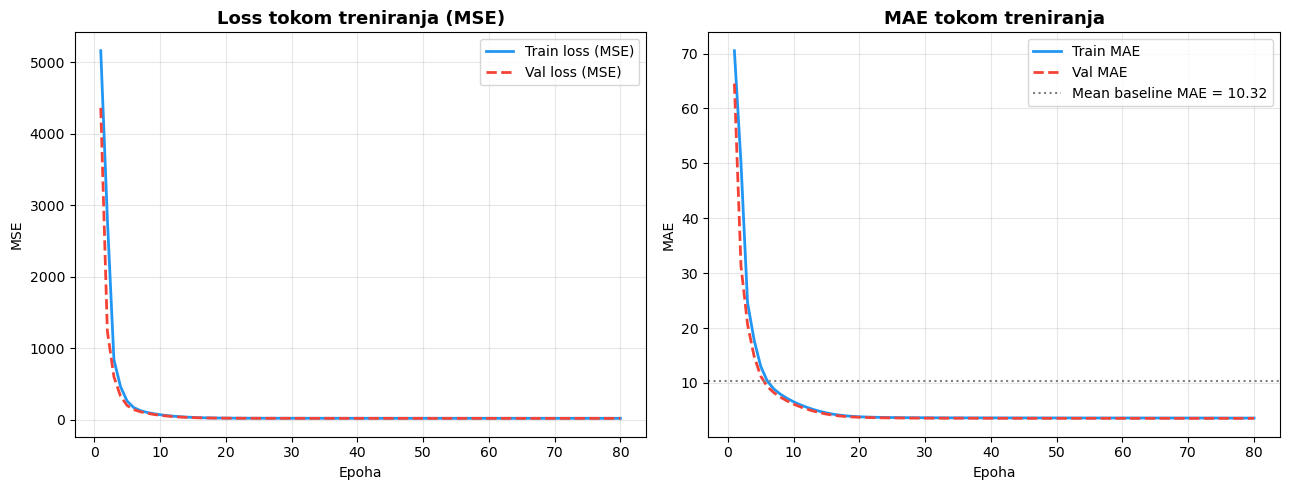

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val loss (MSE)', color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history.history['val_mae'],
             label='Val MAE', color='#F44336', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline MAE = {mae_baseline:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
test_loss, test_mae = baseline_model.evaluate(X_test_s, y_test, verbose=0)
y_pred = baseline_model.predict(X_test_s, verbose=0).flatten()

test_rmse = np.sqrt(test_loss)
test_r2   = r2_score(y_test, y_pred)

print("=" * 55)
print("EVALUACIJA — Baseline SleepNet (Test set)")
print("=" * 55)
print(f"  MAE:  {test_mae:.4f}   (baseline: {mae_baseline:.4f})")
print(f"  RMSE: {test_rmse:.4f}   (baseline: {rmse_baseline:.4f})")
print(f"  R²:   {test_r2:.4f}   (baseline: {r2_baseline:.4f})")
print("-" * 55)
print(f"  Poboljšanje MAE:  {mae_baseline - test_mae:+.4f}")
print(f"  Poboljšanje R²:   {test_r2 - r2_baseline:+.4f}")
print("=" * 55)

EVALUACIJA — Baseline SleepNet (Test set)
  MAE:  3.5548   (baseline: 10.3249)
  RMSE: 4.4594   (baseline: 12.9558)
  R²:   0.8815   (baseline: -0.0001)
-------------------------------------------------------
  Poboljšanje MAE:  +6.7701
  Poboljšanje R²:   +0.8816


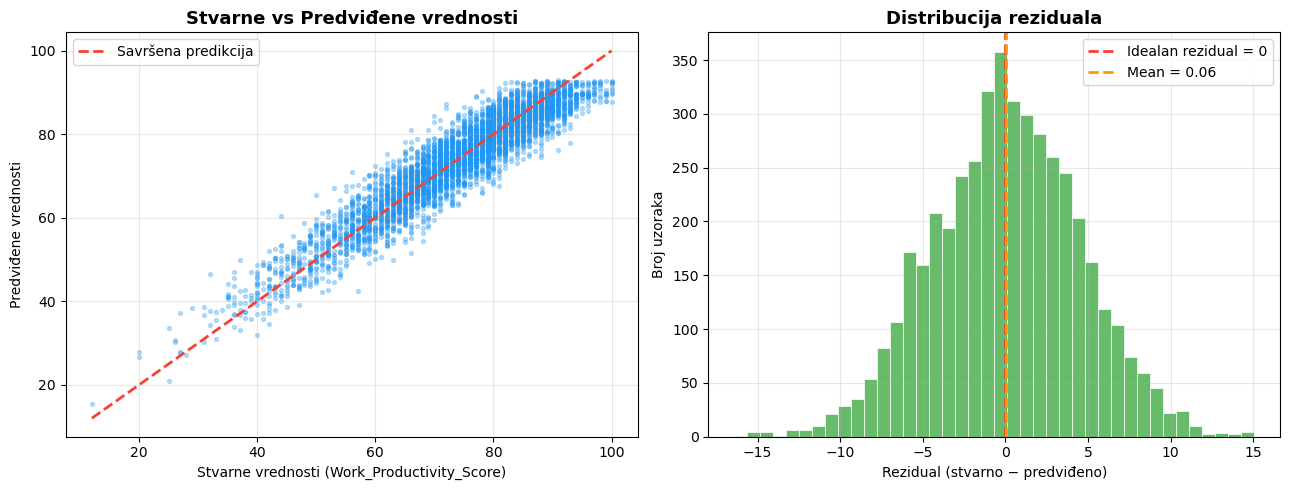

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals.mean():.2f}')
axes[1].set_title('Distribucija reziduala', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
def build_final_model(input_dim, dropout_rate=0.2, l2_lambda=1e-4):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(dropout_rate, name="dropout_1")(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(dropout_rate, name="dropout_2")(x)

    x = layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Dropout(dropout_rate / 2, name="dropout_3")(x)

    x = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_4"
    )(x)
    x = layers.BatchNormalization(name="bn_4")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Final_SleepNet")
    return model

final_model = build_final_model(input_dim=X_train_s.shape[1])
final_model.summary()

Model: "Final_SleepNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,233 (184.50 KB)

 Trainable params: 46,273 (180.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [26]:
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [27]:
callbacks_final = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

In [28]:
history_final = final_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=150,
    batch_size=256,
    callbacks=callbacks_final,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_final.history['loss'])}")
print(f"Finalna train MAE:      {history_final.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_final.history['val_mae'][-1]:.4f}")

Epoch 1/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5445.2964 - mae: 73.2928 - val_loss: 5189.1211 - val_mae: 71.4930 - learning_rate: 0.0010
Epoch 2/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5220.7754 - mae: 72.0505 - val_loss: 4767.6787 - val_mae: 68.7291 - learning_rate: 0.0010
Epoch 3/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4918.4800 - mae: 69.9547 - val_loss: 4733.1235 - val_mae: 68.5699 - learning_rate: 0.0010
Epoch 4/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4497.3428 - mae: 66.8695 - val_loss: 4438.1675 - val_mae: 66.3897 - learning_rate: 0.0010
Epoch 5/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3962.3257 - mae: 62.7475 - val_loss: 3815.5217 - val_mae: 61.5691 - learning_rate: 0.0010
Epoch 6/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3358.0178 - mae: 57.7270 - val_loss: 3101.3433 - val_mae: 55.5050 - learning_rate: 0.0010
Epoch 7/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2731.6470 - mae: 52.0161 - val_loss: 2420.0759 

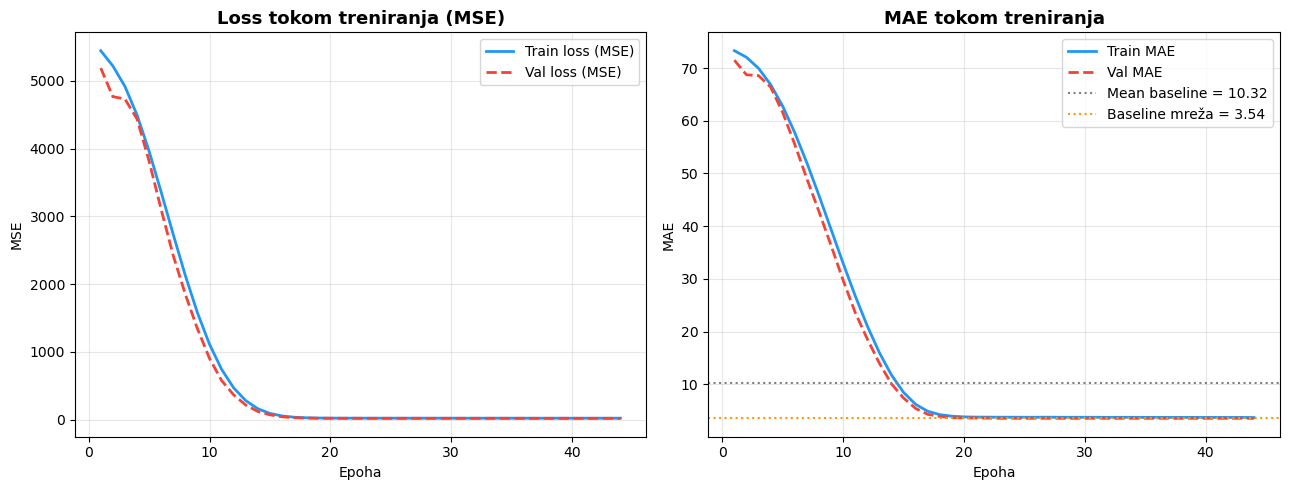

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_final.history['loss']) + 1)

axes[0].plot(epochs_range, history_final.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history_final.history['val_loss'],
             label='Val loss (MSE)', color='#F44336',
             linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_final.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history_final.history['val_mae'],
             label='Val MAE', color='#F44336',
             linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=history.history['val_mae'][-1], color='#FF9800',
                linestyle=':', linewidth=1.5,
                label=f'Baseline mreža = {history.history["val_mae"][-1]:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
test_loss_f, test_mae_f = final_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_f = final_model.predict(X_test_s, verbose=0).flatten()

test_rmse_f = np.sqrt(test_loss_f)
test_r2_f   = r2_score(y_test, y_pred_f)

print("=" * 60)
print("POREĐENJE MODELA — Test set")
print("=" * 60)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 60)
print(f"{'Mean Predictor':<25} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f}")
print(f"{'Baseline SleepNet':<25} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f}")
print(f"{'Final SleepNet':<25} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f}")
print("=" * 60)
print(f"\nPoboljšanje finalnog vs baseline mreže:")
print(f"  MAE:  {test_mae - test_mae_f:+.4f}")
print(f"  RMSE: {test_rmse - test_rmse_f:+.4f}")
print(f"  R²:   {test_r2_f - test_r2:+.4f}")

POREĐENJE MODELA — Test set
Model                          MAE     RMSE       R²
------------------------------------------------------------
Mean Predictor             10.3249  12.9558  -0.0001
Baseline SleepNet           3.5548   4.4594   0.8815
Final SleepNet              3.5612   4.4708   0.8811

Poboljšanje finalnog vs baseline mreže:
  MAE:  -0.0064
  RMSE: -0.0114
  R²:   -0.0004


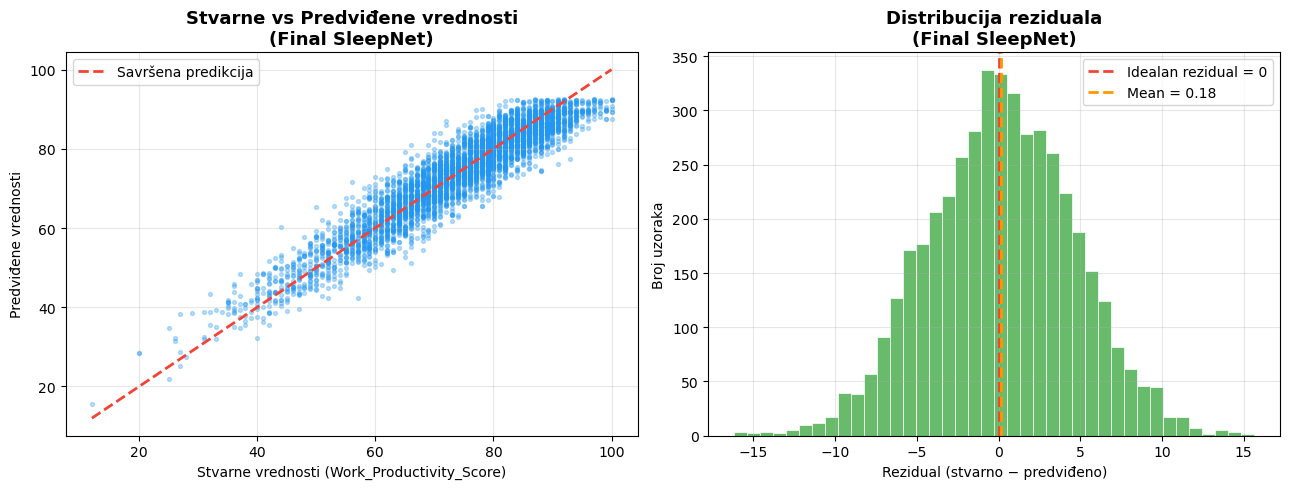

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_f, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2,
             linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Final SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_f = y_test - y_pred_f
axes[1].hist(residuals_f, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_f.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_f.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Final SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

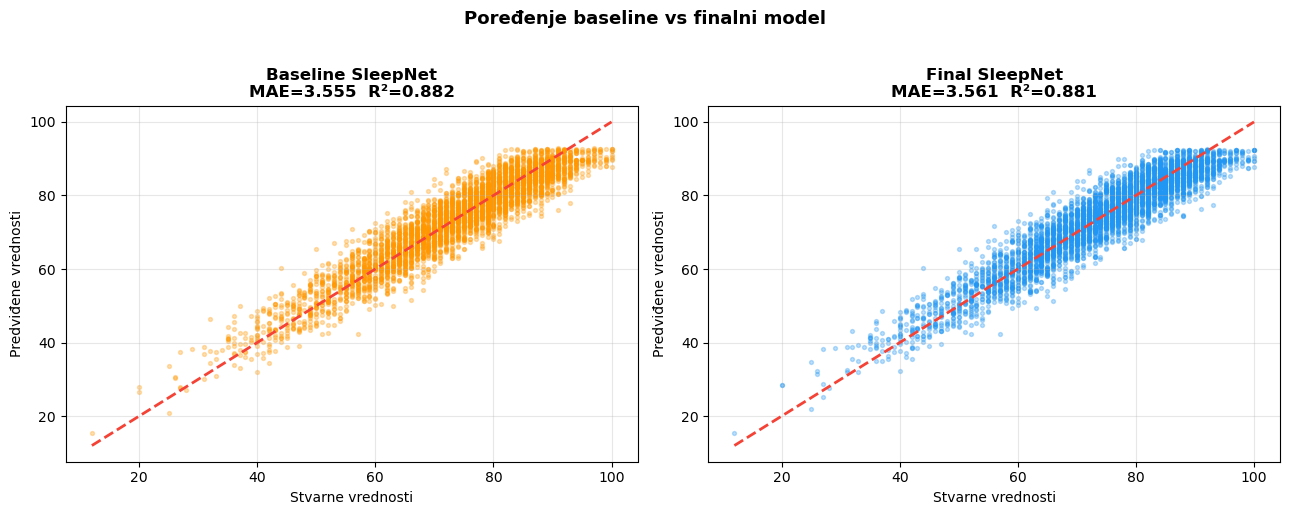

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#FF9800')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title(f'Baseline SleepNet\nMAE={test_mae:.3f}  R²={test_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_f, alpha=0.3, s=8, color='#2196F3')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--')
axes[1].set_title(f'Final SleepNet\nMAE={test_mae_f:.3f}  R²={test_r2_f:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Stvarne vrednosti')
axes[1].set_ylabel('Predviđene vrednosti')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Poređenje baseline vs finalni model',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
def build_final_model_v2(input_dim, l2_lambda=1e-4):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(0.1, name="dropout_1")(x)

    x = layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(0.1, name="dropout_2")(x)

    x = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Final_SleepNet_v2")
    return model

final_model_v2 = build_final_model_v2(input_dim=X_train_s.shape[1])
final_model_v2.summary()

Model: "Final_SleepNet_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,841 (46.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [35]:
final_model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [36]:
callbacks_v2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [37]:
history_v2 = final_model_v2.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=200,
    batch_size=256,
    callbacks=callbacks_v2,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_v2.history['loss'])}")
print(f"Finalna train MAE:      {history_v2.history['mae'][-1]:.4f}")
print(f"Finalna validation MAE: {history_v2.history['val_mae'][-1]:.4f}")

Epoch 1/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5431.0176 - mae: 73.2421 - val_loss: 5189.5703 - val_mae: 71.5012 - learning_rate: 0.0010
Epoch 2/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5195.4443 - mae: 71.8966 - val_loss: 4842.9976 - val_mae: 69.3176 - learning_rate: 0.0010
Epoch 3/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4884.2134 - mae: 69.7072 - val_loss: 4803.0952 - val_mae: 69.1071 - learning_rate: 0.0010
Epoch 4/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4449.6597 - mae: 66.5176 - val_loss: 4360.1133 - val_mae: 65.8437 - learning_rate: 0.0010
Epoch 5/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3905.3210 - mae: 62.2952 - val_loss: 3673.2703 - val_mae: 60.4329 - learning_rate: 0.0010
Epoch 6/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3299.2195 - mae: 57.2189 - val_loss: 3000.6970 - val_mae: 54.5943 - learning_rate: 0.0010
Epoch 7/200
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2675.2510 - mae: 51.4762 - val_loss: 2364.6045 

In [38]:
test_loss_v2, test_mae_v2 = final_model_v2.evaluate(X_test_s, y_test, verbose=0)
y_pred_v2 = final_model_v2.predict(X_test_s, verbose=0).flatten()

test_rmse_v2 = np.sqrt(test_loss_v2)
test_r2_v2   = r2_score(y_test, y_pred_v2)

print("=" * 65)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 65)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7}")
print("-" * 65)
print(f"{'Mean Predictor':<25} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7}")
print(f"{'Baseline SleepNet':<25} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {'80':>7}")
print(f"{'Final SleepNet v1':<25} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {'44':>7}")
print(f"{'Final SleepNet v2':<25} {test_mae_v2:>8.4f} {test_rmse_v2:>8.4f} {test_r2_v2:>8.4f} {len(history_v2.history['loss']):>7}")
print("=" * 65)

POREĐENJE SVIH MODELA — Test set
Model                          MAE     RMSE       R²   Epohe
-----------------------------------------------------------------
Mean Predictor             10.3249  12.9558  -0.0001       —
Baseline SleepNet           3.5548   4.4594   0.8815      80
Final SleepNet v1           3.5612   4.4708   0.8811      44
Final SleepNet v2           3.5611   4.4666   0.8812      55
